In [1]:
import warnings
warnings.filterwarnings('ignore')
from popsycle import synthetic
from popsycle import utils
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
import synthpop
import pdb
import time

# SynthPop

This is where you generate the stellar model. Start by initializing SynthPop object with the configuration of your choice.
This may take a few minutes if it needs to download isochrones and/or several seconds to load a large extinction map file.

For PopSyCLE, it is required to use the popsycle_post_processing module to get your data in the right format. Additionally, you must use absolute magnitudes and use filters that PopSyCLE can interpret.

In [2]:
sp_mod = synthpop.SynthPop('huston2025_defaults.synthpop_conf', # set default figuration, then set any overrides as kwargs
                           output_location="synthpop_output",  # where to place the synthpop output
                           obsmag = False, # keep magnitudes in absolute
                           name_for_output='synthpopsycle', output_filename_pattern="{name_for_output}_l{l_deg:.3f}_b{b_deg:.3f}", #how to name the output
                           post_processing_kwargs = [{"name":"ProcessDarkCompactObjects", "remove":False, "ifmr_name":'SukhboldN20',
                                                     "kick_mean_ns":350, "kick_mean_bh":100}, # IFMR + kick velocities
                                {"name": "popsycle_post_processing"}], # Module to format catalog for PopSyCLE
                           chosen_bands=["Bessell_U", "Bessell_B", "Bessell_V", "Bessell_R", "Bessell_I", "2MASS_J", "2MASS_H", "2MASS_Ks"],
                           maglim=['Bessell_U',99,'keep'],
                           extinction_map_kwargs = {"name":"maps_from_dustmaps", "dustmap_name":"marshall"} #{"name":"surot"}
                          )
sp_mod.init_populations()

 2045 - Execution Date: 13-08-2025 16:23:24


################################ Settings #################################
 2045 - # reading default parameters from
 2046 - default_config_file =  /Users/mhuston/code/synthpop/synthpop/config_files/_default.synthpop_conf 
 2046 - # read configuration from 
 2046 - config_file = '/Users/mhuston/code/synthpop/synthpop/config_files/huston2025_defaults.synthpop_conf' 


# copy the following to a config file to redo this model generation -------
 2047 - {
    "l_set": null,
    "l_set_type": null,
    "b_set": null,
    "b_set_type": null,
    "name_for_output": "synthpopsycle",
    "model_name": "Huston2025",
    "solid_angle": null,
    "solid_angle_unit": "deg^2",
    "random_seed": 192050230,
    "sun": {
        "x": -8.178,
        "y": 0.0,
        "z": 0.017,
        "u": 12.9,
        "v": 245.6,
        "w": 7.78,
        "l_apex_deg": 56.24,
        "b_apex_deg": 22.54
    },
    "lsr": {
        "u_lsr": 1.8,
        "v_lsr": 233.4

Then, run the specific sightline you want

In [11]:
t0=time.time()
_ = sp_mod.process_location(-1, -1.2, # first, enter l and b in degrees
                            solid_angle=1e-3, solid_angle_unit='deg^2', # solid angle can be in deg^2 or sr
                            save_data=False) # this prevents synthpop from saving in its default format, it will already be saved via popsycle_post_processing
print(f'Synthpop catalog generated in {np.round((time.time()-t0)/60, 2)} minutes.')



############################# update location #############################
 41787 - # set location to: 
 41788 - l, b = (-1.00 deg, -1.20 deg)
 41789 - # set solid_angle to:
 41790 - solid_angle = 1.000e-03 deg^2


############################# Generate Field ##############################


# Population 0;  bulge ----------------------------------------------------
 43684 - # From density profile (number density)
 43685 - expected_total_iMass = 434076.8231
 43685 - expected_total_eMass = 237632.4186
 43685 - average_iMass_per_star = 0.5739
 43685 - mass_loss_correction = 0.5474
 43686 - n_expected_stars = 756408.0440
 43686 - # Determine velocities when position are generated 


  0%|          | 0/755846 [00:00<?, ?it/s]

 58418 - # From Generated Field:
 58418 - generated_stars = 755846
 58427 - generated_total_iMass = 433087.6384
 58476 - generated_total_eMass = 236787.1567
 58489 - det_mass_loss_corr = 0.5467
 59241 - # Done


# Population 1;  halo -----------------------------------------------------
 59601 - # From density profile (number density)
 59601 - expected_total_iMass = 536.7212
 59601 - expected_total_eMass = 281.7621
 59602 - average_iMass_per_star = 0.5739
 59602 - mass_loss_correction = 0.5250
 59602 - n_expected_stars = 935.2727
 59603 - # Determine velocities when position are generated 
 59694 - # From Generated Field:
 59694 - generated_stars = 949
 59694 - generated_total_iMass = 543.4185
 59698 - generated_total_eMass = 278.9787
 59698 - det_mass_loss_corr = 0.5134
 59702 - # Done


# Population 2;  nsd ------------------------------------------------------
 60715 - # From density profile (number density)
 60715 - expected_total_iMass = 2067.0085
 60715 - expected_total_eMass = 1

PopSyCLE formatted output saved in synthpop_output/synthpopsycle_l-1.000_b-1.200_psc.h5
Synthpop catalog generated in 0.49 minutes.


# Finding microlensing events

Here is when all microlensing events are found.
You can set the survey duration, cadence, maximum impact parameter, blend radius.
This also has the option of being parallelizable.

In [19]:
synthetic.calc_events(hdf5_file = "synthpop_output/synthpopsycle_l-1.000_b-1.200_psc.h5", 
                      output_root2 = 'synthpop_output/synthpopsycle_l-1.000_b-1.200_psc', 
                      radius_cut = 2, 
                      obs_time = 1000, 
                      n_obs = 11, 
                      theta_frac = 2, 
                      blend_rad = 0.65, 
                      overwrite = True, 
                      n_proc = 4)

/Users/mhuston/anaconda3/lib/python3.11/site-packages/pysynphot/locations.py:345: UserWarning: Extinction files not found in /Users/mhuston/NotBacked/spisea_data/cdbs/extinction
  warnings.warn('Extinction files not found in %s' % (extdir, ))


Working on loop ll, bb =  0 0
Candidate events detected:  173
calc_events runtime : 20.541712 s


# Photometry

This is the last thing, where you choose the photometric band for the observations and the reddening law.
The final file of microlensing events is produced here as a .fits file.

In [20]:
synthetic.refine_events(input_root = 'synthpop_output/synthpopsycle_l-1.000_b-1.200_psc', 
                        filter_name = 'I',
                        photometric_system = 'ubv',
                        red_law = 'Damineli16', 
                        overwrite = True, 
                        output_file = 'default',
                        galactic_model_code = 'synthpop')

Original candidate events:  135
Candidate events in survey window:  121
refine_events runtime : 0.137473 s


# Things you can do with PopSyCLE

First, read in the table, and print out a list of all the possible keys:

In [14]:
t = Table.read('synthpop_output/synthpopsycle_l-1.000_b-1.200_psc_refined_events_ubv_I_Damineli16.fits')
print(t.colnames)

['zams_mass_L', 'mass_L', 'systemMass_L', 'px_L', 'py_L', 'pz_L', 'vx_L', 'vy_L', 'vz_L', 'vr_L', 'mu_lcosb_L', 'mu_b_L', 'exbv_L', 'glat_L', 'glon_L', 'mbol_L', 'grav_L', 'teff_L', 'feh_L', 'rad_L', 'ubv_U_L', 'ubv_B_L', 'ubv_V_L', 'ubv_R_L', 'ubv_I_L', 'ubv_J_L', 'ubv_H_L', 'ubv_K_L', 'isMultiple_L', 'N_companions_L', 'rem_id_L', 'obj_id_L', 'zams_mass_S', 'mass_S', 'systemMass_S', 'px_S', 'py_S', 'pz_S', 'vx_S', 'vy_S', 'vz_S', 'vr_S', 'mu_lcosb_S', 'mu_b_S', 'exbv_S', 'glat_S', 'glon_S', 'mbol_S', 'grav_S', 'teff_S', 'feh_S', 'rad_S', 'ubv_U_S', 'ubv_B_S', 'ubv_V_S', 'ubv_R_S', 'ubv_I_S', 'ubv_J_S', 'ubv_H_S', 'ubv_K_S', 'isMultiple_S', 'N_companions_S', 'rem_id_S', 'obj_id_S', 'theta_E', 'u0', 'mu_rel', 't0', 't_E', 'ubv_I_app_S', 'ubv_I_app_L', 'cent_glon_I_N', 'cent_glat_I_N', 'ubv_I_app_N', 'ubv_I_app_LSN', 'delta_m_I', 'f_blend_I', 'pi_rel', 'pi_E', 'pps_seed', 'gal_seed']


## Figure out how many events due to BH, NS, WD, star

In [15]:
bh_idx = np.where(t['rem_id_L'] == 103)[0]
ns_idx = np.where(t['rem_id_L'] == 102)[0]
wd_idx = np.where(t['rem_id_L'] == 101)[0]
st_idx = np.where(t['rem_id_L'] == 0)[0]
print('Number of BHs: ' + str(len(bh_idx)))
print('Number of NSs: ' + str(len(ns_idx)))
print('Number of WDs: ' + str(len(wd_idx)))
print('Number of stars: ' + str(len(st_idx)))

Number of BHs: 1
Number of NSs: 1
Number of WDs: 22
Number of stars: 97


## Histogram of tE

Text(0.5, 0, '$t_E$ (days)')

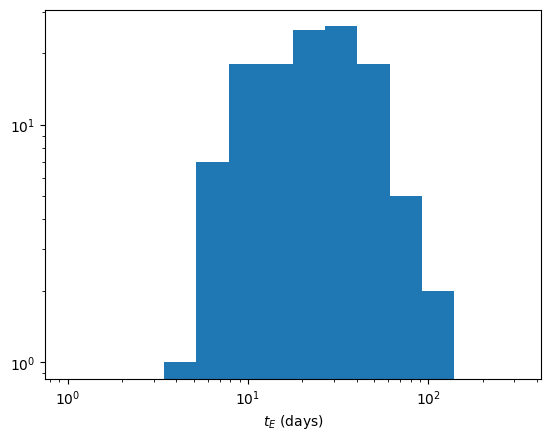

In [16]:
plt.hist(t['t_E'], bins = np.logspace(0, 2.5, 15))
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$t_E$ (days)')

## piE vs tE

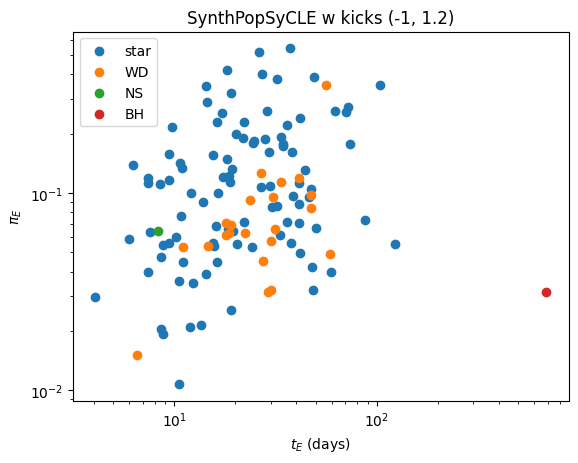

In [17]:
lens_type={0:'star', 101:'WD', 102:'NS', 103:'BH'}
for rem_id in np.unique(t['rem_id_L']):
    idxs = np.where(t['rem_id_L']==rem_id)[0]
    plt.scatter(t['t_E'][idxs], t['pi_E'][idxs], label=lens_type[rem_id])
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$t_E$ (days)')
plt.ylabel('$\pi_E$')
plt.legend(loc=2)
plt.title('SynthPopSyCLE w kicks (-1, 1.2)')
plt.savefig('synthpopsycle_lenstype.png')

## dL vs dS

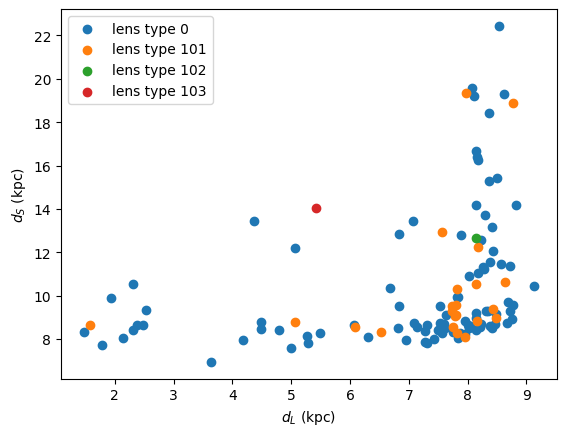

In [18]:
for rem_id in np.unique(t['rem_id_L']):
    idxs = np.where(t['rem_id_L']==rem_id)[0]
    plt.scatter(t['rad_L'][idxs], t['rad_S'][idxs], label='lens type '+str(rem_id))
plt.xlabel('$d_L$ (kpc)')
plt.ylabel('$d_S$ (kpc)')
plt.legend()